<a href="https://colab.research.google.com/github/gabrielluisnunes/Teste/blob/main/Welcome_To_Colaboratory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset carregado com sucesso!
  id_tarefa      tipo prioridade  tempo_estimado_horas  tempo_real_horas  \
0      T001       Bug      Média                   8.0               6.0   
1      T002  Melhoria      Baixa                  15.3              16.4   
2      T003  Melhoria       Alta                   9.2               8.6   
3      T004  Melhoria       Alta                  14.9              14.2   
4      T005       Bug      Baixa                  12.6               8.9   

  desenvolvedor nivel_experiencia        status  qtd_reaberturas  \
0         Bruno             Pleno     Concluída                0   
1         Bruno             Pleno  Em andamento                0   
2           Ana            Júnior     Concluída                0   
3      Henrique            Sênior     Concluída                0   
4      Gabriela             Pleno     Concl

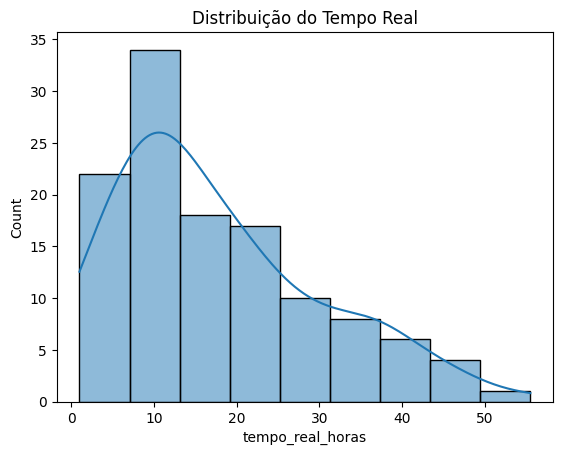

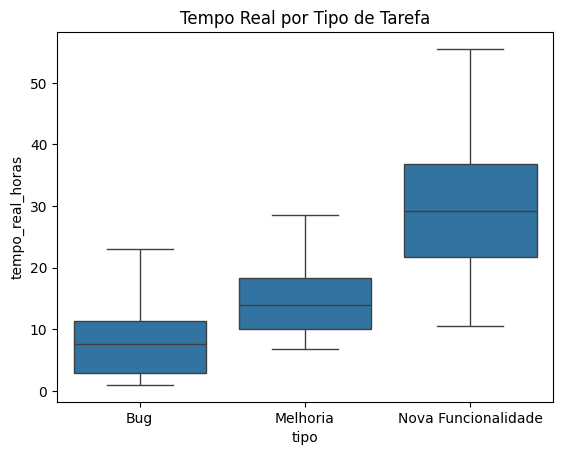

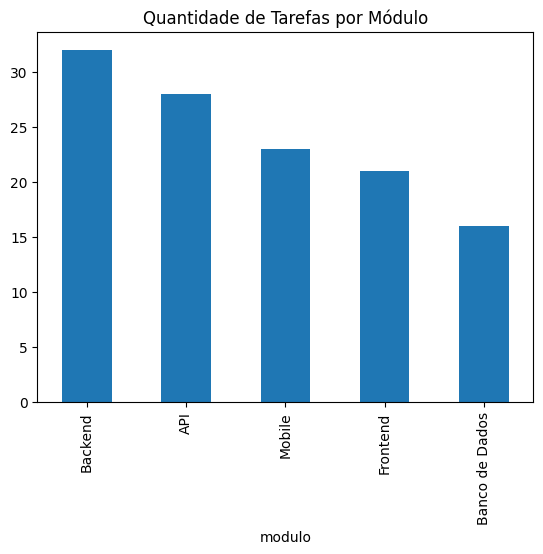

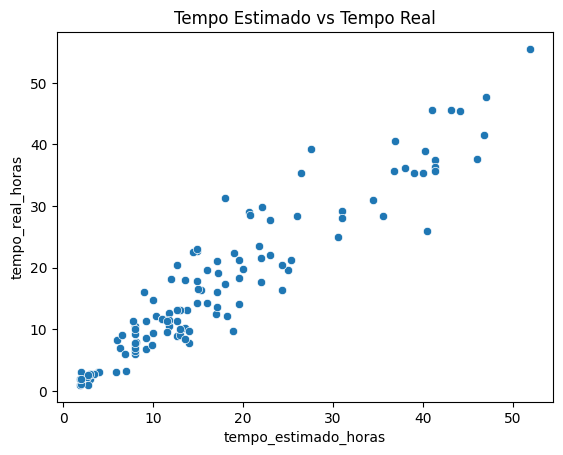

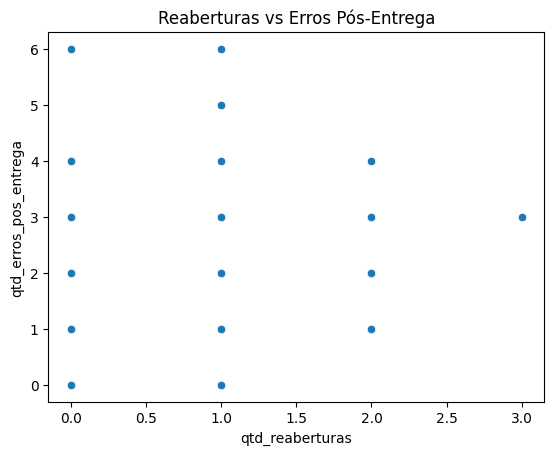


Tempo médio real:
17.616666666666667

Diferença média por tipo:
tipo
Bug                   -0.220000
Melhoria              -0.218750
Nova Funcionalidade   -0.048837
Name: desvio_tempo, dtype: float64

Módulos com mais atraso:
modulo
Backend           15
API               12
Frontend           9
Banco de Dados     7
Mobile             6
Name: count, dtype: int64

Erros por nível de experiência:
nivel_experiencia
Júnior    2.290323
Pleno     1.796296
Sênior    1.028571
Name: qtd_erros_pos_entrega, dtype: float64


In [4]:
# ===============================
# 1. CONECTAR AO GOOGLE DRIVE
# ===============================
from google.colab import drive
drive.mount('/content/drive')

# ===============================
# 2. IMPORTAR BIBLIOTECAS
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 3. CARREGAR DATASET
# ===============================
path = "/content/drive/MyDrive/atividadepy/dataset_engenharia_software_eda.csv"

df = pd.read_csv(path)

print("Dataset carregado com sucesso!")
print(df.head())

# ===============================
# 4. ENTENDIMENTO DOS DADOS
# ===============================
print("\nINFO:")
print(df.info())

print("\nDESCRIBE:")
print(df.describe())

print("\nVALORES NULOS:")
print(df.isnull().sum())

# ===============================
# 5. CRIAR VARIÁVEIS NOVAS
# ===============================
df["desvio_tempo"] = df["tempo_real_horas"] - df["tempo_estimado_horas"]

df["cumpriu_prazo"] = df["desvio_tempo"].apply(
    lambda x: "Sim" if x <= 0 else "Não"
)

# ===============================
# 6. GRÁFICOS
# ===============================

# Histograma
plt.figure()
sns.histplot(df["tempo_real_horas"], kde=True)
plt.title("Distribuição do Tempo Real")
plt.show()

# Boxplot por tipo
plt.figure()
sns.boxplot(x="tipo", y="tempo_real_horas", data=df)
plt.title("Tempo Real por Tipo de Tarefa")
plt.show()

# Gráfico de barras por módulo
plt.figure()
df["modulo"].value_counts().plot(kind="bar")
plt.title("Quantidade de Tarefas por Módulo")
plt.show()

# Scatter estimado vs real
plt.figure()
sns.scatterplot(x="tempo_estimado_horas", y="tempo_real_horas", data=df)
plt.title("Tempo Estimado vs Tempo Real")
plt.show()

# Scatter reabertura vs erros
plt.figure()
sns.scatterplot(x="qtd_reaberturas", y="qtd_erros_pos_entrega", data=df)
plt.title("Reaberturas vs Erros Pós-Entrega")
plt.show()

# ===============================
# 7. ANÁLISES IMPORTANTES
# ===============================

print("\nTempo médio real:")
print(df["tempo_real_horas"].mean())

print("\nDiferença média por tipo:")
print(df.groupby("tipo")["desvio_tempo"].mean())

print("\nMódulos com mais atraso:")
print(df[df["cumpriu_prazo"] == "Não"]["modulo"].value_counts())

print("\nErros por nível de experiência:")
print(df.groupby("nivel_experiencia")["qtd_erros_pos_entrega"].mean())